# Set up and imports

In [1457]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn


In [1458]:
los_df=pd.read_csv(r"/Users/mussabasif/hospital-los-prediction/hospital-los-prediction/data/LengthOfStay.csv")
los_df.head()


,eid,vdate,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,...,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid,lengthofstay
0,1,8/29/2012,0,F,0,0,0,0,0,0,...,192.476918,12.0,1.390722,30.432418,96,6.5,4,9/1/2012,B,3
1,2,5/26/2012,5+,F,0,0,0,0,0,0,...,94.078507,8.0,0.943164,28.460516,61,6.5,1,6/2/2012,A,7
2,3,9/22/2012,1,F,0,0,0,0,0,0,...,130.530524,12.0,1.065750,28.843812,64,6.5,2,9/25/2012,B,3
3,4,8/9/2012,0,F,0,0,0,0,0,0,...,163.377028,12.0,0.906862,27.959007,76,6.5,1,8/10/2012,A,1
4,5,12/20/2012,0,F,0,0,0,1,0,1,...,94.886654,11.5,1.242854,30.258927,67,5.6,2,12/24/2012,E,4


In [1459]:
los_df.shape
# has 28 columns and 100,000 rows

(100000, 28)

In [1460]:
los_df.columns
# reviewing all columns that are part of the dataset, to drop those that are not necessary. 

Index(['eid', 'vdate', 'rcount', 'gender', 'dialysisrenalendstage', 'asthma',
       'irondef', 'pneum', 'substancedependence', 'psychologicaldisordermajor',
       'depress', 'psychother', 'fibrosisandother', 'malnutrition', 'hemo',
       'hematocrit', 'neutrophils', 'sodium', 'glucose', 'bloodureanitro',
       'creatinine', 'bmi', 'pulse', 'respiration',
       'secondarydiagnosisnonicd9', 'discharged', 'facid', 'lengthofstay'],
      dtype='object')

In [1461]:
# Checking for datatype for all columns
los_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   eid                         100000 non-null  int64  
 1   vdate                       100000 non-null  object 
 2   rcount                      100000 non-null  object 
 3   gender                      100000 non-null  object 
 4   dialysisrenalendstage       100000 non-null  int64  
 5   asthma                      100000 non-null  int64  
 6   irondef                     100000 non-null  int64  
 7   pneum                       100000 non-null  int64  
 8   substancedependence         100000 non-null  int64  
 9   psychologicaldisordermajor  100000 non-null  int64  
 10  depress                     100000 non-null  int64  
 11  psychother                  100000 non-null  int64  
 12  fibrosisandother            100000 non-null  int64  
 13  malnutrition   

In [1462]:
# reviewing statistically signifcant values of columns part of the dataset. 
los_df.describe().T

,count,mean,std,min,25%,50%,75%,max
eid,100000.0,50000.500000,28867.657797,1.000000,25000.750000,50000.500000,75000.250000,100000.000000
dialysisrenalendstage,100000.0,0.036420,0.187334,0.000000,0.000000,0.000000,0.000000,1.000000
asthma,100000.0,0.035270,0.184462,0.000000,0.000000,0.000000,0.000000,1.000000
irondef,100000.0,0.094940,0.293134,0.000000,0.000000,0.000000,0.000000,1.000000
pneum,100000.0,0.039450,0.194664,0.000000,0.000000,0.000000,0.000000,1.000000
substancedependence,100000.0,0.063060,0.243072,0.000000,0.000000,0.000000,0.000000,1.000000
psychologicaldisordermajor,100000.0,0.239040,0.426499,0.000000,0.000000,0.000000,0.000000,1.000000
depress,100000.0,0.051660,0.221341,0.000000,0.000000,0.000000,0.000000,1.000000
psychother,100000.0,0.049390,0.216682,0.000000,0.000000,0.000000,0.000000,1.000000
fibrosisandother,100000.0,0.004790,0.069044,0.000000,0.000000,0.000000,0.000000,1.000000


In [1463]:
# ensuring if the dataset has any duplicate rows
los_df.duplicated().sum()


np.int64(0)

# Distribution of the target variable

## Length of stay count plot

<Axes: xlabel='lengthofstay'>

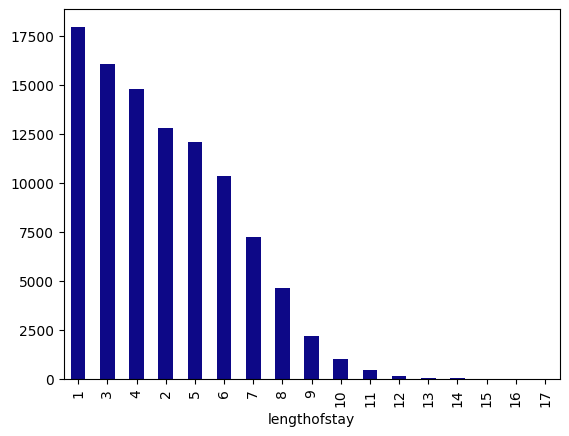

In [1464]:
fig, ax= plt.subplots()
los_count=los_df['lengthofstay'].value_counts()
los_count.plot(kind='bar', colormap='plasma')

## Distribution of key predictors

### Blood urea nitro

In [1465]:
bun_values=los_df['bloodureanitro']
print(bun_values.mean())
print(bun_values.median())

14.09718461904265
12.0


{'whiskers': [<matplotlib.lines.Line2D at 0x357980820>,
 'caps': [<matplotlib.lines.Line2D at 0x357980d60>,
 'boxes': [<matplotlib.lines.Line2D at 0x357980580>],
 'medians': [<matplotlib.lines.Line2D at 0x3579902e0>],
 'fliers': [<matplotlib.lines.Line2D at 0x357990580>],
 'means': []}

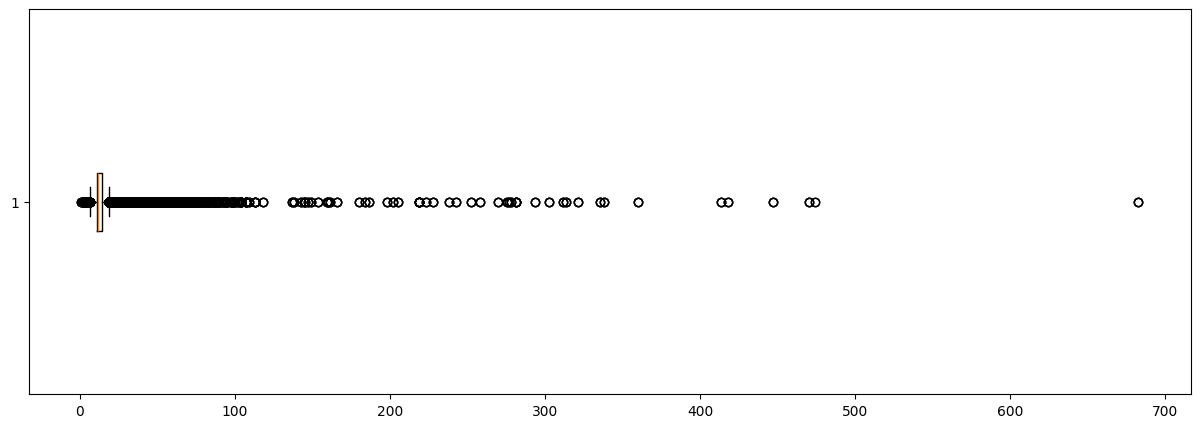

In [1466]:
fig=plt.figure(figsize=(15, 5))
plt.boxplot(bun_values, vert=False)

#### As visible from the box plot, blood urea nitrogen levels for a few patients are extremely high. We will drop those values since the number of patients with BUN with values greater than 200 is only 92


In [1467]:
los_df = los_df[los_df['bloodureanitro']<200]
los_df
# df after tha values have been dropped

,eid,vdate,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,...,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid,lengthofstay
0,1,8/29/2012,0,F,0,0,0,0,0,0,...,192.476918,12.0,1.390722,30.432418,96,6.5,4,9/1/2012,B,3
1,2,5/26/2012,5+,F,0,0,0,0,0,0,...,94.078507,8.0,0.943164,28.460516,61,6.5,1,6/2/2012,A,7
2,3,9/22/2012,1,F,0,0,0,0,0,0,...,130.530524,12.0,1.065750,28.843812,64,6.5,2,9/25/2012,B,3
3,4,8/9/2012,0,F,0,0,0,0,0,0,...,163.377028,12.0,0.906862,27.959007,76,6.5,1,8/10/2012,A,1
4,5,12/20/2012,0,F,0,0,0,1,0,1,...,94.886654,11.5,1.242854,30.258927,67,5.6,2,12/24/2012,E,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,1/28/2012,3,M,0,0,0,0,0,0,...,171.422555,12.0,0.650323,30.063069,80,6.5,1,2/3/2012,B,6
99996,99997,8/6/2012,0,M,0,0,0,0,0,0,...,122.342450,12.0,1.521424,28.969548,61,6.5,1,8/7/2012,B,1
99997,99998,7/23/2012,1,M,0,0,1,0,0,0,...,108.288106,12.0,1.025677,26.354919,61,6.9,1,7/27/2012,C,4
99998,99999,12/19/2012,0,M,0,0,0,0,0,0,...,111.750731,16.0,1.035400,29.193462,59,5.6,1,12/23/2012,B,4


{'whiskers': [<matplotlib.lines.Line2D at 0x3579e86a0>,
 'caps': [<matplotlib.lines.Line2D at 0x3579e8be0>,
 'boxes': [<matplotlib.lines.Line2D at 0x3579e8340>],
 'medians': [<matplotlib.lines.Line2D at 0x3579f7160>],
 'fliers': [<matplotlib.lines.Line2D at 0x3579f7400>],
 'means': []}

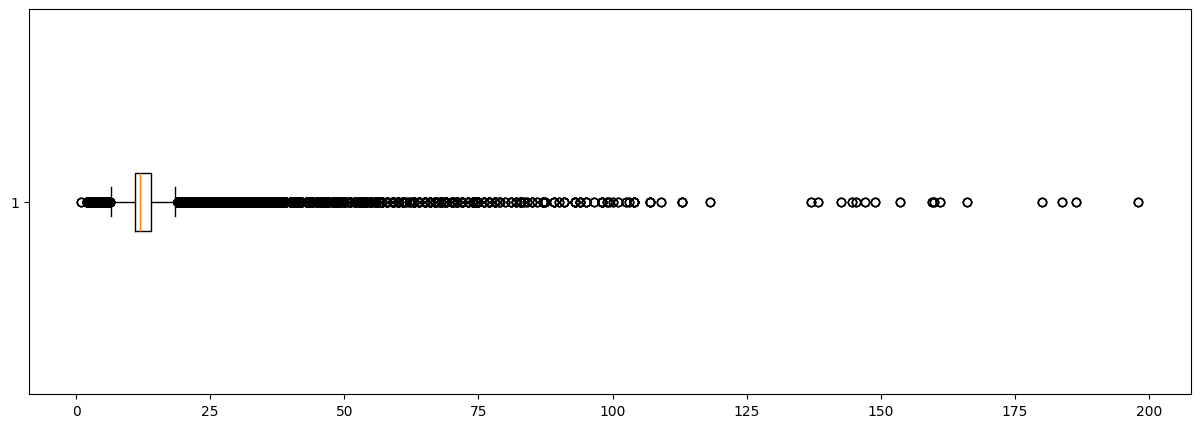

In [1468]:
fig=plt.figure(figsize=(15, 5))
plt.boxplot(los_df['bloodureanitro'], vert=False)

### Neutrophils

#### From the box plot, we can tell that there may be a unit scaling mismatch. Typical healthy values range anywhere between between 2,500 and 7,000 cells per microliter of blood. Values greater than 100,000 were dropped from the dataset. 

np.float64(245.9)

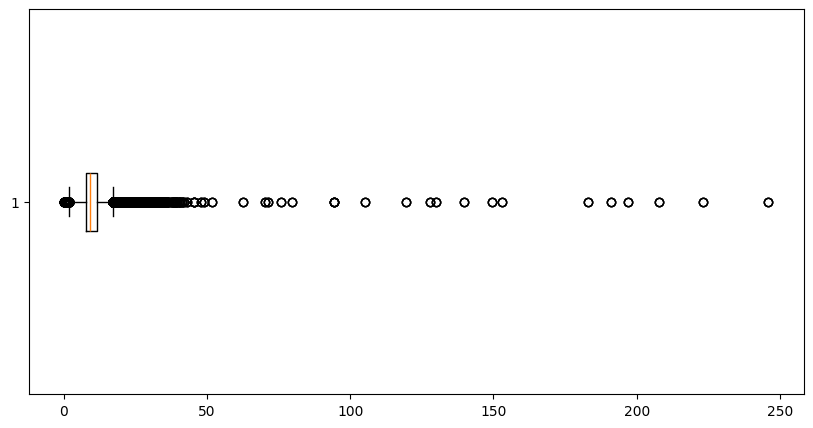

In [1469]:
fig=plt.figure(figsize=(10, 5))
plt.boxplot(los_df['neutrophils'], vert=False)
los_df['neutrophils'].max()

In [1470]:
los_df['neutrophils']=los_df['neutrophils']*1000
los_df['neutrophils'].min()
#
#fig=plt.figure(figsize=(10, 5))
#plt.boxplot(los_df['neutrophils'], vert=False)

np.float64(100.0)

In [1471]:
upper_extreme_neu_values=los_df['neutrophils']>100000
upper_extreme_neu_values.value_counts()
# since the number of values that are beyond the extreme threshold only 39, we can safely drop those rows. 

neutrophils
False    99869
True        39
Name: count, dtype: int64

In [1472]:
los_df = los_df[los_df['neutrophils']<100001]
los_df['neutrophils']

0        14200.0
1         4100.0
2         8900.0
3         9400.0
4         9050.0
          ...   
99995     9300.0
99996     9300.0
99997     7700.0
99998     8200.0
99999    14200.0
Name: neutrophils, Length: 99869, dtype: float64

0        14200.0
1         4100.0
2         8900.0
3         9400.0
4         9050.0
          ...   
99995     9300.0
99996     9300.0
99997     7700.0
99998     8200.0
99999    14200.0
Name: neutrophils, Length: 99869, dtype: float64

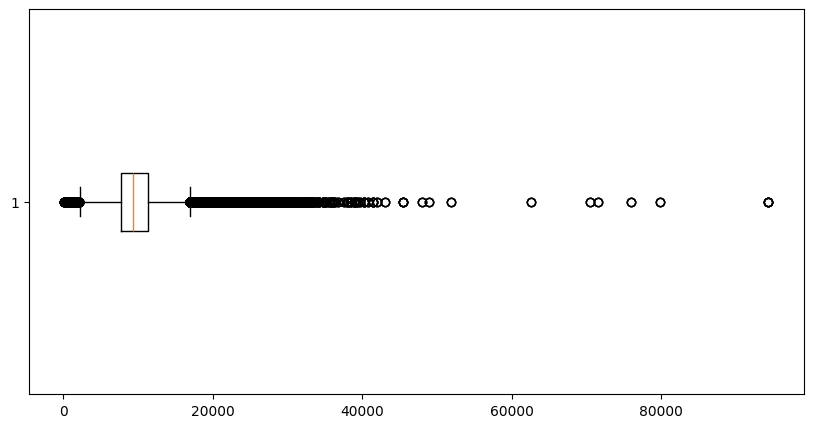

In [1473]:
fig=plt.figure(figsize=(10, 5))
plt.boxplot(los_df['neutrophils'], vert=False)
los_df['neutrophils']

### bmi

Text(0.5, 0, 'BMI score')

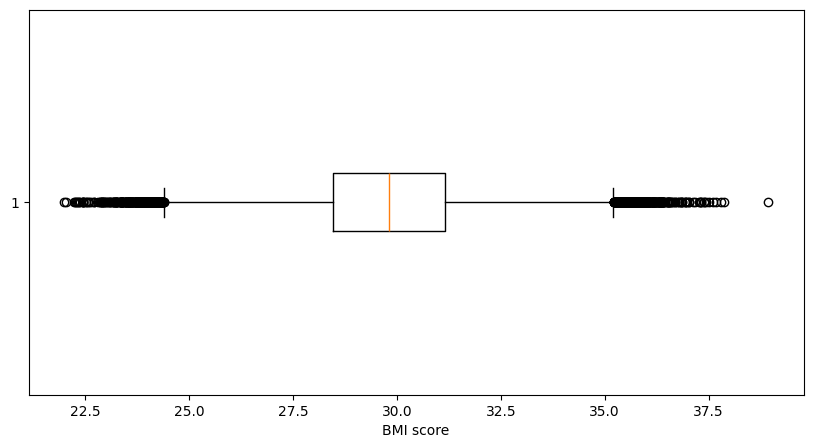

In [1474]:
fig=plt.figure(figsize=(10, 5))
bmi_value=los_df['bmi']
plt.boxplot(bmi_value,vert=False )
plt.xlabel('BMI score')



### glucose

Text(0.5, 0, 'Glucose values')

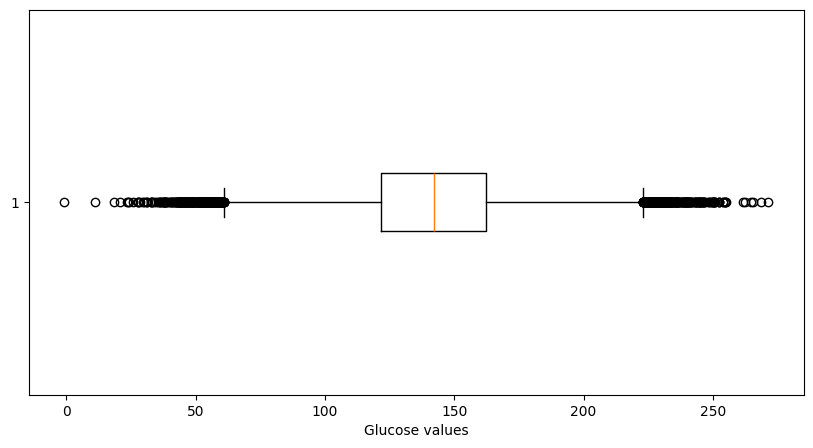

In [1475]:
fig=plt.figure(figsize=(10, 5))
glucose_values=los_df['glucose']
plt.boxplot(glucose_values, vert=False)
plt.xlabel('Glucose values')


### Pulse

/Users/mussabasif/hospital-los-prediction/hospital-los-prediction/.venv/lib/python3.9/site-packages/IPython/core/displayhook.py:281: UserWarning: Output cache limit (currently 1000 entries) hit.
Flushing oldest 200 entries.
  warn('Output cache limit (currently {sz} entries) hit.\n'


Text(0.5, 0, 'pulse values')

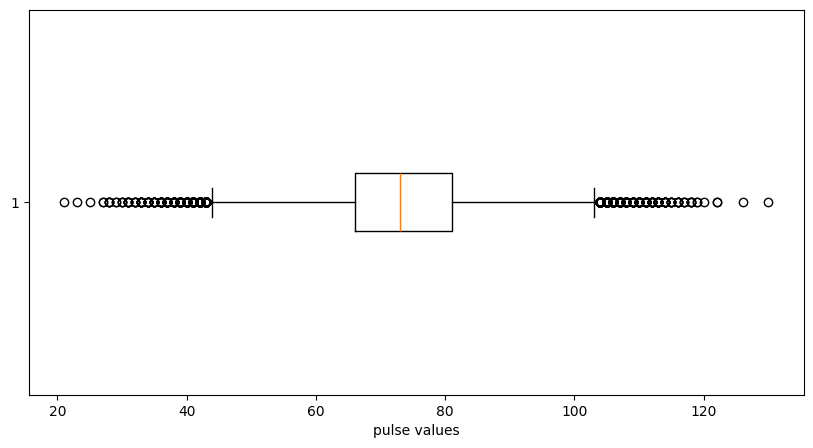

In [1476]:

fig=plt.figure(figsize=(10, 5))
pulse_values=los_df['pulse']
plt.boxplot(pulse_values, vert=False)
plt.xlabel('pulse values')

### Creatinine

Text(0.5, 0, 'creatinine')

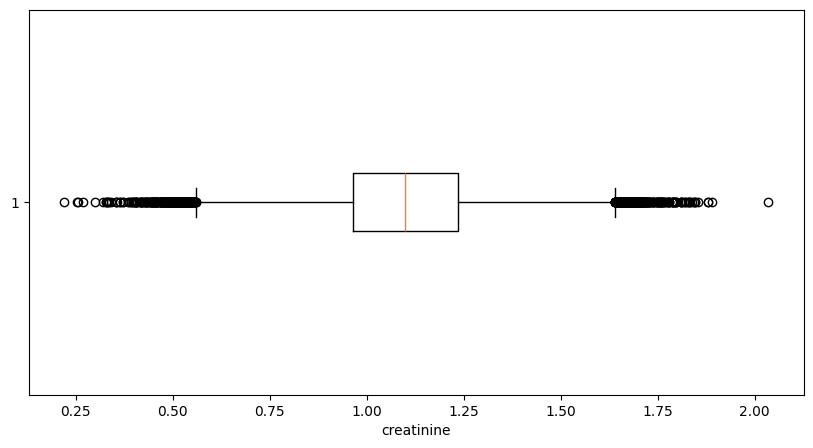

In [1477]:
fig=plt.figure(figsize=(10, 5))
creatinine_values=los_df['creatinine']
plt.boxplot(creatinine_values, vert=False)
plt.xlabel('creatinine')


### Sodium

{'whiskers': [<matplotlib.lines.Line2D at 0x357c1a220>,
 'caps': [<matplotlib.lines.Line2D at 0x357bbb1c0>,
 'boxes': [<matplotlib.lines.Line2D at 0x357c0bf40>],
 'medians': [<matplotlib.lines.Line2D at 0x357c1a670>],
 'fliers': [<matplotlib.lines.Line2D at 0x357c1a910>],
 'means': []}

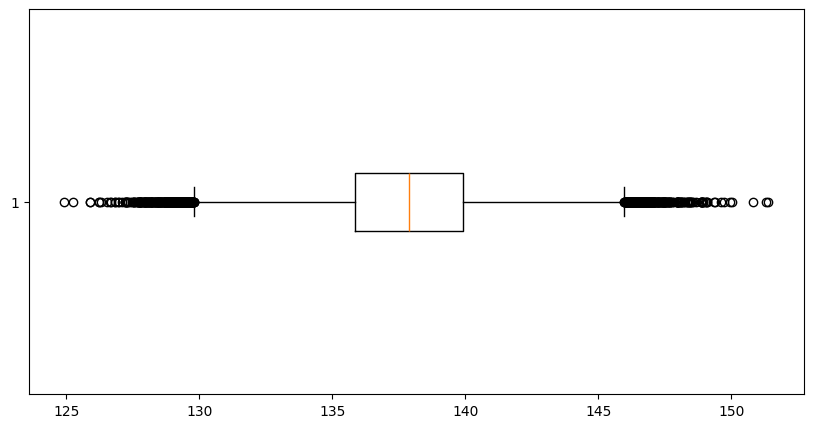

In [1478]:
fig=plt.figure(figsize=(10, 5))
sodium_values=los_df['sodium']
plt.boxplot(sodium_values, vert=False)

### Hemoglobin

{'whiskers': [<matplotlib.lines.Line2D at 0x357c76b20>,
 'caps': [<matplotlib.lines.Line2D at 0x357c880a0>,
 'boxes': [<matplotlib.lines.Line2D at 0x357c76880>],
 'medians': [<matplotlib.lines.Line2D at 0x357c885e0>],
 'fliers': [<matplotlib.lines.Line2D at 0x357c88880>],
 'means': []}

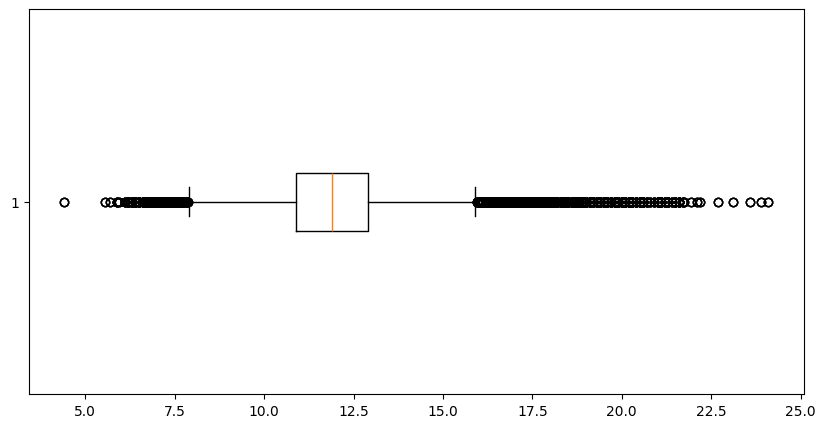

In [1479]:
fig=plt.figure(figsize=(10, 5))
hematocrit_values=los_df['hematocrit']
plt.boxplot(hematocrit_values, vert=False)



### Respiration

#### This column seems very artificial since the values should range between 12-20. More than 65% of the values for respiration in this dataset are 6.5 only. 

{'whiskers': [<matplotlib.lines.Line2D at 0x357cecc40>,
 'caps': [<matplotlib.lines.Line2D at 0x357cfe1c0>,
 'boxes': [<matplotlib.lines.Line2D at 0x357cec9a0>],
 'medians': [<matplotlib.lines.Line2D at 0x357cfe700>],
 'fliers': [<matplotlib.lines.Line2D at 0x357c29f40>],
 'means': []}

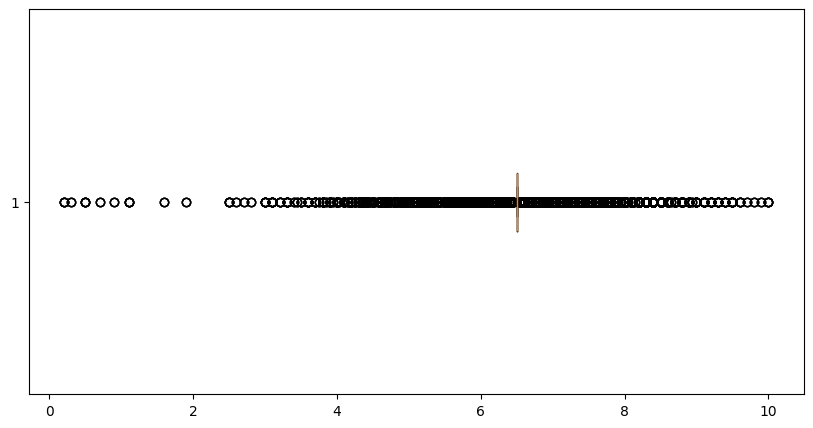

In [1480]:
fig=plt.figure(figsize=(10, 5))
plt.boxplot(los_df['respiration'], vert=False)

In [1481]:
q1 = los_df['respiration'].quantile(0.25)
q3 = los_df['respiration'].quantile(0.75)
iqr = q3 - q1
low_limit = q1 - 1.5 * iqr
up_limit = q3 + 1.5* iqr
print(low_limit, up_limit)

6.5 6.5


In [1482]:
los_df['respiration'].value_counts()

respiration
6.500000    64788
6.400000     1524
6.200000     1489
6.600000     1473
6.300000     1447
            ...  
2.800000        3
1.600000        3
5.575000        2
6.166667        2
5.933333        2
Name: count, Length: 159, dtype: int64

### Distribtion of Categorical variables

#### Readmission count

In [1483]:
los_df['rcount']
# sicne this column has a max value of 5+, i will be replacing 5+ with 5 only. 

0         0
1        5+
2         1
3         0
4         0
         ..
99995     3
99996     0
99997     1
99998     0
99999     0
Name: rcount, Length: 99869, dtype: object

In [1484]:
los_df.rcount.replace(['5+'], [5], inplace=True)

/var/folders/0g/0rngkrh11rz7p3c55850pvjc0000gn/T/ipykernel_23375/685886374.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  los_df.rcount.replace(['5+'], [5], inplace=True)


#### Gender

In [1485]:
los_df['gender']

0        F
1        F
2        F
3        F
4        F
        ..
99995    M
99996    M
99997    M
99998    M
99999    F
Name: gender, Length: 99869, dtype: object

#### Admission/Discharge date
##### Both will be dropped since the dataset already provides us with LOS column

In [1486]:
los_df=los_df.drop(['vdate', 'discharged'], axis=1)

In [1487]:
los_df['facid'].unique()

array(['B', 'A', 'E', 'D', 'C'], dtype=object)

#### Check for all columns to ensure values are strcitly 1/0. 

In [1488]:
binary_cols = ['dialysisrenalendstage', 'asthma', 'irondef', 'pneum', 'substancedependence', 'psychologicaldisordermajor', 'depress', 'psychother', 'fibrosisandother', 'malnutrition', 'hemo']

for col in binary_cols:
    print(col, los_df[col].unique())

dialysisrenalendstage [0 1]
asthma [0 1]
irondef [0 1]
pneum [0 1]
substancedependence [0 1]
psychologicaldisordermajor [0 1]
depress [0 1]
psychother [0 1]
fibrosisandother [0 1]
malnutrition [0 1]
hemo [0 1]
